# Trabajo Práctico: Clasificación de Imágenes con Datasets Públicos

## Dataset:
Intel Image Classification (Kaggle)

## Link:

https://www.kaggle.com/datasets/puneet6060/intel-image-classification?utm_source=chatgpt.com

## Objetivo

Comparar dos modelos:

- Modelo A: CNN simple
- Modelo B: Transfer Learning con MobileNetV2

In [1]:
!pip install kaggle

# Descarga del dataset

Se utilizará Kaggle API para descargar el dataset público.

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lautarobenavidez","key":"951ca3f381e6e28071cd55d2871739f1"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip intel-image-classification.zip -d intel_dataset


Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: intel_dataset/seg_train/seg_train/mountain/7506.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7537.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7539.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7551.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7560.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7565.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7578.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7581.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7586.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7647.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7652.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7654.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7662.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/767.jpg  
  

# Importación de librerías

Se cargan TensorFlow, NumPy, Matplotlib y Scikit-learn.

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

# Configuración inicial

In [6]:
train_dir = "/content/intel_dataset/seg_train/seg_train"
test_dir = "/content/intel_dataset/seg_test/seg_test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
SEED = 123

# Carga de imágenes

Se divide el dataset en entrenamiento, validación y test.

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 14034 files belonging to 6 classes.
Using 11929 files for training.
Found 14034 files belonging to 6 classes.
Using 2105 files for validation.
Found 3000 files belonging to 6 classes.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Visualización de ejemplos

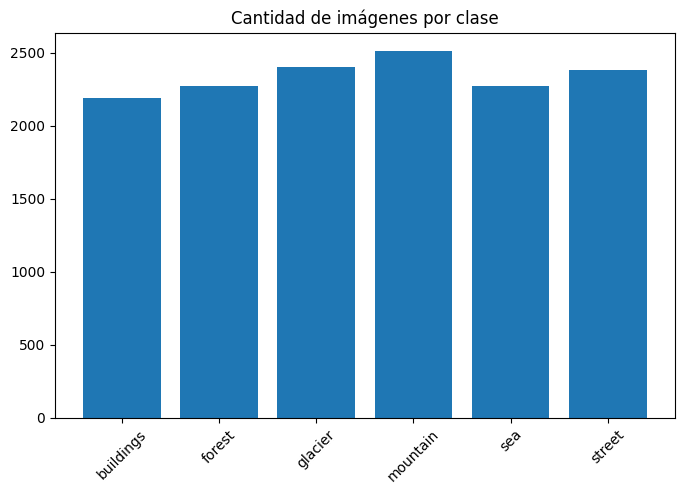

{'buildings': 2191,
 'forest': 2271,
 'glacier': 2404,
 'mountain': 2512,
 'sea': 2274,
 'street': 2382}

In [8]:
import pathlib
from collections import Counter

counts = {}
for clase in class_names:
    path = pathlib.Path(train_dir) / clase
    counts[clase] = len(list(path.glob("*")))

plt.figure(figsize=(8,5))
plt.bar(counts.keys(), counts.values())
plt.title("Cantidad de imágenes por clase")
plt.xticks(rotation=45)
plt.show()

counts

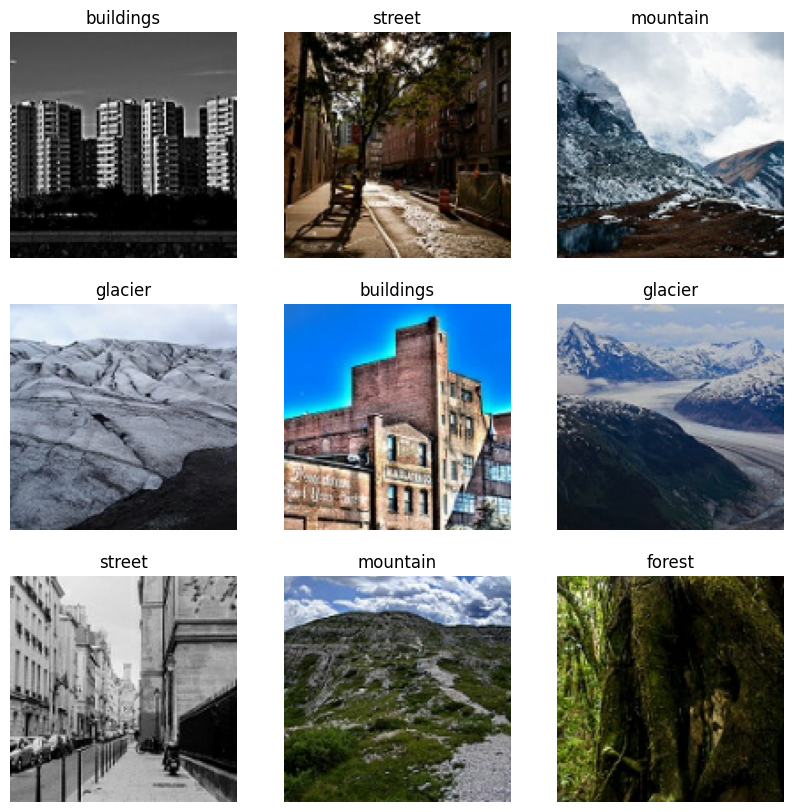

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

# Optimización y Data Augmentation

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Modelo A: CNN Base

In [20]:
model_a = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),0
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model_a.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_a = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 406s 541ms/step - accuracy: 0.5365 - loss: 1.1938 - val_accuracy: 0.6209 - val_loss: 0.9842
Epoch 2/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 400s 537ms/step - accuracy: 0.6277 - loss: 0.9784 - val_accuracy: 0.6646 - val_loss: 0.8697
Epoch 3/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 443s 539ms/step - accuracy: 0.6737 - loss: 0.8888 - val_accuracy: 0.7349 - val_loss: 0.7439
Epoch 4/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 405s 544ms/step - accuracy: 0.7024 - loss: 0.8296 - val_accuracy: 0.7468 - val_loss: 0.6849
Epoch 5/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 434s 534ms/step - accuracy: 0.7221 - loss: 0.7671 - val_accuracy: 0.7705 - val_loss: 0.6610
Epoch 6/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 402s 539ms/step - accuracy: 0.7430 - loss: 0.7278 - val_accuracy: 0.7506 - val_loss: 0.6900
Epoch 7/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 408s 547ms/step - accuracy: 0.7474 - loss: 0.7037 - val_accuracy: 0.7743 - val_loss: 0.6402
Epoch 8/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 399s 534ms/step - accuracy: 0.7597 -

# Modelo B: Transfer Learning

In [18]:
base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model_b = models.Sequential([
    layers.Input(shape=(128,128,3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_b = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 234s 293ms/step - accuracy: 0.8080 - loss: 0.5335 - val_accuracy: 0.8907 - val_loss: 0.2944
Epoch 2/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 242s 278ms/step - accuracy: 0.8567 - loss: 0.3915 - val_accuracy: 0.8964 - val_loss: 0.2791
Epoch 3/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 194s 260ms/step - accuracy: 0.8637 - loss: 0.3727 - val_accuracy: 0.9074 - val_loss: 0.2756
Epoch 4/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 202s 260ms/step - accuracy: 0.8683 - loss: 0.3583 - val_accuracy: 0.9088 - val_loss: 0.2669
Epoch 5/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 191s 256ms/step - accuracy: 0.8689 - loss: 0.3593 - val_accuracy: 0.9055 - val_loss: 0.2679
Epoch 6/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 199s 267ms/step - accuracy: 0.8714 - loss: 0.3567 - val_accuracy: 0.8893 - val_loss: 0.2868
Epoch 7/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 196s 262ms/step - accuracy: 0.8722 - loss: 0.3570 - val_accuracy: 0.8917 - val_loss: 0.2835
Epoch 8/10
746/746 ━━━━━━━━

# Curvas de entrenamiento

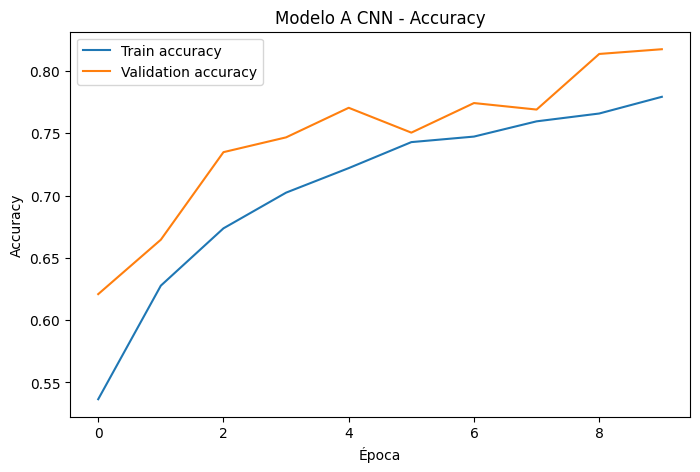

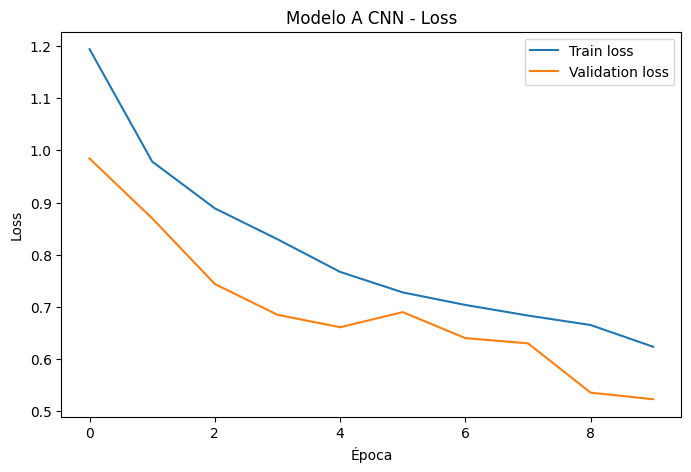

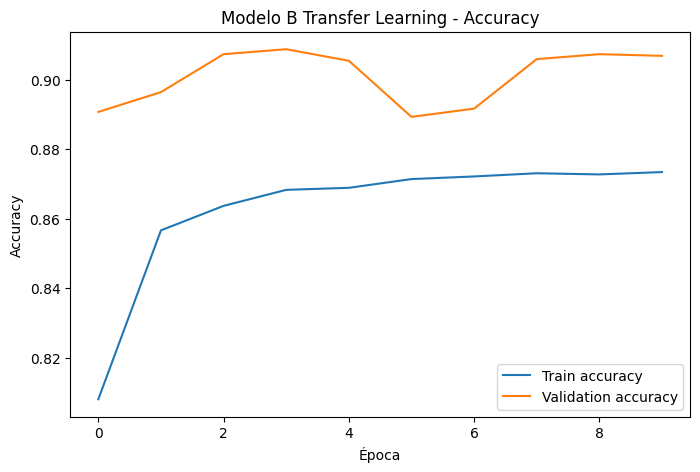

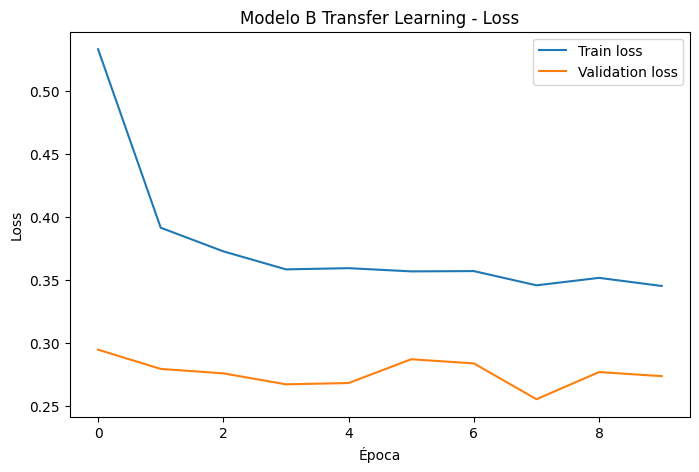

In [21]:
def plot_history(history, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history["accuracy"], label="Train accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_a, "Modelo A CNN")
plot_history(history_b, "Modelo B Transfer Learning")

# Evaluación final

Modelo A
              precision    recall  f1-score   support

   buildings       0.72      0.83      0.77       437
      forest       0.95      0.93      0.94       474
     glacier       0.81      0.74      0.77       553
    mountain       0.76      0.77      0.76       525
         sea       0.81      0.77      0.79       510
      street       0.83      0.84      0.83       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



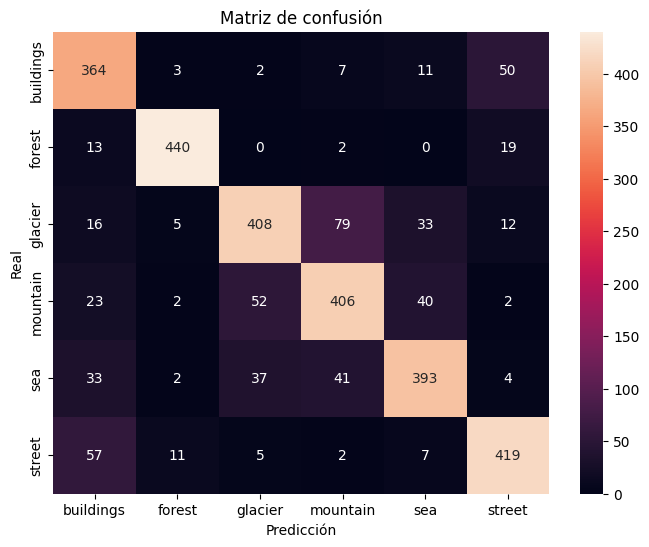

Modelo B
              precision    recall  f1-score   support

   buildings       0.91      0.90      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.80      0.84       553
    mountain       0.85      0.87      0.86       525
         sea       0.88      0.98      0.93       510
      street       0.93      0.90      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



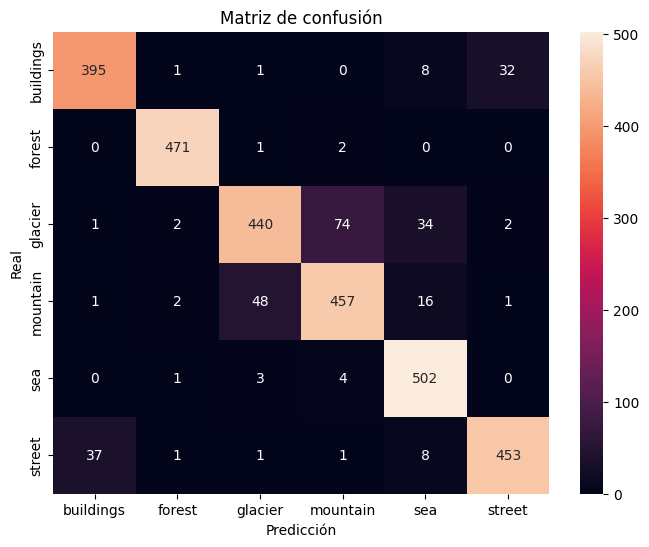

In [22]:
def evaluate_model(model, test_ds, class_names):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de confusión")
    plt.show()

    return y_true, y_pred

print("Modelo A")
y_true_a, y_pred_a = evaluate_model(model_a, test_ds, class_names)

print("Modelo B")
y_true_b, y_pred_b = evaluate_model(model_b, test_ds, class_names)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Modelo": ["CNN simple", "Transfer Learning MobileNetV2"],
    "Accuracy": [
        accuracy_score(y_true_a, y_pred_a),
        accuracy_score(y_true_b, y_pred_b)
    ],
    "Precision weighted": [
        precision_score(y_true_a, y_pred_a, average="weighted"),
        precision_score(y_true_b, y_pred_b, average="weighted")
    ],
    "Recall weighted": [
        recall_score(y_true_a, y_pred_a, average="weighted"),
        recall_score(y_true_b, y_pred_b, average="weighted")
    ],
    "F1 weighted": [
        f1_score(y_true_a, y_pred_a, average="weighted"),
        f1_score(y_true_b, y_pred_b, average="weighted")
    ]
})

results

,Modelo,Accuracy,Precision weighted,Recall weighted,F1 weighted
0,CNN simple,0.810,0.812794,0.810,0.810352
1,Transfer Learning MobileNetV2,0.906,0.906368,0.906,0.905177


In [24]:
for images, labels in test_ds.take(1):
    preds = model_b.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12,12))
    count = 0

    for i in range(len(labels)):
        if labels[i] != pred_labels[i] and count < 9:
            ax = plt.subplot(3,3,count+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Real: {class_names[labels[i]]}\nPred: {class_names[pred_labels[i]]}")
            plt.axis("off")
            count += 1

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step


<Figure size 1200x1200 with 0 Axes>

# Preguntas guía — Análisis final

## ¿Qué clase fue la más difícil de clasificar y por qué?

En los resultados podemos ver que la clase más difícil de clasificar fue **glacier**. En el Modelo A obtuvo un F1-score de 0.77 y en el Modelo B siguió siendo una de las categorías con menor recall (0.80). En las matrices de confusión se observa que muchas imágenes de glacier fueron confundidas con **mountain** y también con **sea**. Esto ocurre porque comparten características visuales similares, como nieve, rocas, agua y tonalidades frías, lo que dificulta diferenciarlas con precisión.

## ¿Detectaron overfitting? ¿Cómo lo identificaron?

No se detectó un overfitting marcado. En las gráficas se observa que la accuracy de entrenamiento y validación crecen de forma similar, mientras que la loss disminuye en ambos casos. Además, no aparece una separación grande entre las curvas de train y validation. Esto indica que los modelos aprendieron correctamente sin memorizar los datos de entrenamiento.

## ¿Qué impacto tuvo el data augmentation?

El data augmentation tuvo un impacto positivo en el entrenamiento. Al aplicar rotaciones, zoom y flips horizontales, el modelo recibió imágenes variadas a partir de los datos originales. Esto ayudó a mejorar la generalización y redujo la posibilidad de sobreajuste. Los resultados finales muestran que fue una estrategia útil para lograr modelos más estables.

## ¿Por qué el transfer learning suele funcionar mejor con pocos datos?

El transfer learning suele funcionar mejor con pocos datos porque utiliza modelos ya entrenados con millones de imágenes. Esos modelos ya aprendieron patrones generales como bordes, formas y texturas. Luego solo se adaptan las capas finales al nuevo problema. En este trabajo se comprobó claramente, ya que el Modelo A obtuvo una accuracy de 0.81 y el Modelo B alcanzó 0.91.

## Si quisieran llevar este modelo a producción, ¿qué revisarían antes?

Antes de llevar este modelo a producción habría que revisar varios aspectos. Primero, probarlo con imágenes reales externas al dataset. También medir la velocidad de predicción y el consumo de recursos. Además, sería importante analizar errores frecuentes entre clases parecidas, comprobar su funcionamiento con imágenes borrosas o de baja calidad, y monitorear el rendimiento con el tiempo para reentrenarlo si fuera necesario.

#Resumen del trabajo

En este trabajo se desarrolló un sistema de clasificación de imágenes utilizando el dataset Intel Image Classification de Kaggle, compuesto por seis categorías de escenas naturales y urbanas.

Se implementaron dos enfoques distintos. El primero consistió en una red neuronal convolucional simple entrenada desde cero. El segundo utilizó transfer learning con MobileNetV2 preentrenado.

Los resultados mostraron una diferencia clara entre ambos modelos. La CNN base alcanzó una accuracy de 0.81, mientras que el modelo con transfer learning logró 0.91, demostrando mayor capacidad de generalización y mejor rendimiento global.

También se observó que las clases visualmente similares, como glacier y mountain, generaron más errores de clasificación.

En conclusión, el uso de modelos preentrenados representa una estrategia muy eficiente cuando se dispone de recursos limitados o datasets medianos, logrando mejores métricas con menor tiempo de entrenamiento.